# Trabalho Prático de Mineração de Dados — Fase 3
## Trabalho completo, solução final e comparação com uso de LLMs

**Disciplina:** Mineração de Dados  
**Grupo:**
Davi Oliveira Sad - 2023096043 <br>
Gabrielly Xavier dos Santos - 2024023724 <br>
Júlia Luíza Costa de Toledo - 2024008431 <br>
Rafael Vinicius de Sant’Ana Mathias - 2023087834 <br>
**Dataset:** Mushroom  
**Tarefa de mineração:** Padrões Frequentes  
**Data da entrega:** 10/05/2026  


---

## Objetivo deste notebook

Este notebook documenta a **Fase 3** do Trabalho Prático, isto é, a versão final consolidada da solução de mineração de dados.

Nesta fase, o grupo deve:

1. corrigir erros e limitações identificados na Fase 2;
2. consolidar a solução técnica efetivamente implementada;
3. executar a modelagem final;
4. avaliar criticamente os resultados;
5. comparar três elementos:
   - a solução sugerida pela LLM na condição **baseline**;
   - a solução sugerida pela LLM na condição **guiada por diretrizes de IA responsável**;
   - a solução final efetivamente implementada pelo grupo.

> **Importante:** este notebook é um modelo. Ele contém placeholders e trechos de código genéricos. O grupo deve adaptar tudo ao dataset, à tarefa e às decisões reais tomadas no trabalho.

# Como usar este notebook

Este notebook foi estruturado para orientar uma boa entrega final, sem substituir o trabalho do grupo.

Use os campos marcados como:

- `[INSERIR ...]`
- `[DESCREVER ...]`
- `[JUSTIFICAR ...]`
- `[ANALISAR ...]`
- `[PREENCHER ...]`

como indicações de conteúdo que deve ser produzido pelo grupo.

## Diferença em relação à Fase 2

Na Fase 2, o foco estava em documentar e comparar as interações com LLMs.

Na Fase 3, o foco passa a ser a **solução final consolidada**, isto é:

- quais sugestões da LLM foram incorporadas;
- quais foram corrigidas;
- quais foram rejeitadas;
- quais algoritmos e parâmetros foram realmente usados;
- quais resultados foram efetivamente obtidos;
- como os resultados se relacionam ao problema de negócio e às diretrizes de IA responsável.

Não é necessário repetir todos os links completos das conversas da Fase 2, mas a comparação entre baseline, guiada e solução final deve permanecer clara.

# 0. Controle da entrega e rastreabilidade

| Item | Valor |
|---|---|
| Nome do dataset | Mushroom |
| Link público do dataset | https://archive.ics.uci.edu/dataset/73/mushroom |
| Número de linhas | 8.124  |
| Número de colunas | 23 |
| Tarefa de mineração | Mineração de Padrões Frequentes |
| Diretriz 1 de IA responsável | Explicabilidade |
| Diretriz 2 de IA responsável | Monitoramento e Avaliação |
| LLM usada na Fase 2 — baseline | Google Gemini|
| LLM usada na Fase 2 — guiada | Google Gemini|
| Notebook da Fase 2 | https://github.com/DaviOSad/Data-Mining-Mushroom-Analysis/blob/main/TP1_Fase2_Grupo11.ipynb |

## Resumo das decisões herdadas da Fase 2
| Decisão | Origem | Foi mantida na Fase 3? | Justificativa |
| :--- | :--- | :--- | :--- |
| Remoção do atributo veil-type | Baseline e Guiada | Sim | O atributo possui variância zero (100% de valores iguais), não contribuindo para a discriminação entre classes. |
| Tratamento de nulos em stalk-root | Baseline e Guiada | Sim | Mantivemos o valor missing como categoria explícita para preservar 30% dos dados e evitar riscos de imputações artificiais. |
| Prefixação coluna=valor | Guiada | Sim | Essencial para a Explicabilidade. Garante que os itens da transação sejam rastreáveis às suas colunas originais sem ambiguidade. |
| Confiança de 100% para comestíveis | Guiada | Sim | Rigor de Monitoramento. Em segurança biológica, a margem de erro para falsos negativos deve ser nula. |
| Uso do Lift > 1.5 como filtro | Guiada | Sim | Adotado para garantir a força da associação e descartar padrões que ocorrem ao acaso, conforme a diretriz de Avaliação. |
| Agrupamento de categorias raras | Grupo | Não | Rejeitado pelo grupo para preservar a diversidade biológica e não omitir padrões de espécies tóxicas raras. |
| Escolha do algoritmo FP-Growth | Baseline e Grupo | Sim | Optamos pela eficiência computacional. O FP-Growth gerou resultados idênticos ao Apriori em tempo significativamente menor. |
| Uso do Apriori como benchmark | Guiada | Sim | Mantido para fins de auditoria e validação cruzada dos padrões encontrados, garantindo a rastreabilidade da solução. |
| Poda por redundância | Baseline | Sim | Implementada para garantir que apenas as regras mais simples e informativas sejam apresentadas, melhorando a interpretabilidade e evitando tautologias. |

> A rastreabilidade das decisões é parte importante da avaliação. Não basta apresentar o resultado final; é necessário explicar como o grupo chegou até ele.

In [2]:
# Configurações iniciais
import os
import time
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset. 
# Como vocês estão usando o arquivo .data original:
DATA_PATH = "agaricus-lepiota.data"

# Tipo de tarefa consolidado na Fase 2:
TASK_TYPE = "padroes_frequentes"

# Para padrões frequentes, a classe entra na transação, então o alvo aqui é None.
TARGET_COLUMN = None 

# No Mushroom, cada linha é uma transação completa. 
# Deixamos como None para sinalizar que o algoritmo deve processar todas as colunas.
TRANSACTION_COLUMN = None

# Diretório para salvar os resultados
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuração inicial carregada.")
print(f"TASK_TYPE = {TASK_TYPE}")
print(f"DATA_PATH = {DATA_PATH}")

Configuração inicial carregada.
TASK_TYPE = padroes_frequentes
DATA_PATH = agaricus-lepiota.data


# 1. Business Understanding

Nesta seção, o grupo deve consolidar a compreensão do problema, incorporando eventuais correções feitas após a Fase 2.

A versão final deve responder:

1. Qual problema será investigado?
2. Por que o dataset é adequado para esse problema?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da solução?
5. Quais diretrizes de IA responsável foram consideradas?
6. Como essas diretrizes influenciaram a solução final?
7. Quais limitações permanecem mesmo após a consolidação da solução?

## 1.1 Problema de negócio e objetivo analítico
A identificação de espécies fúngicas é uma tarefa crítica onde o erro humano pode ter consequências fatais. Com milhares de espécies descritas, a diferenciação entre cogumelos comestíveis e venenosos exige um cruzamento complexo de características morfológicas que nem sempre são óbvias para leigos ou entusiastas.

**Contexto:** O projeto utiliza o dataset Mushroom, que cataloga amostras das famílias Agaricus e Lepiota. O cenário envolve a necessidade de criar guias de segurança e protocolos de triagem baseados em evidências estatísticas.

**Problema:** A ausência de uma regra única e universal para identificar a toxicidade (ex: "todo cogumelo vermelho é venenoso" é um mito perigoso). A toxicidade é determinada por uma combinação de fatores como odor, cor do esporo, formato do caule e habitat.

**Objetivo analítico:** Extrair regras de associação robustas que identifiquem com 100% de confiança os padrões que levam à classificação de um cogumelo como venenoso ou comestível. Buscamos encontrar "regras mestre" (antecedentes curtos e de alto impacto) que facilitem a memorização e a inspeção visual humana.

**Usuários ou interessados:** Organizações de saúde pública, micologistas, desenvolvedores de aplicativos de identificação biológica e entusiastas de sobrevivência na natureza.

**Decisões apoiadas:** Elaboração de guias de campo, treinamento de equipes de emergência médica para triagem rápida e fundamentação de alertas de segurança baseados em características sensoriais (como o odor).

**Ajustes em relação à Fase 2**
A versão final do projeto reflete refinamentos críticos validados na etapa anterior:

* **Rigor de Segurança e Validação:** Consolidamos a Confiança em 1.0 (100%) para regras de comestibilidade e a obrigatoriedade do Lift > 1.5. Isso garante que as decisões de negócio sejam baseadas em associações estatisticamente fortes e seguras.

* **Foco na Explicabilidade:** Além da tradução léxica (siglas para nomes reais), aplicamos a poda por redundância para filtrar o excesso de informações e entregar apenas as regras que possuem valor prático imediato para o usuário final.

* **Preservação de Dados Críticos:** Rejeitamos a simplificação de categorias raras proposta pela trilha Baseline, priorizando a segurança biológica em detrimento da redução da dimensionalidade.

## 1.2 Dataset, origem e características finais

### Identificação do dataset

- **Nome:** Mushroom Dataset (Agaricus and Lepiota Family)
- **Fonte:** UCI Machine Learning Repository
- **Link público:** (https://archive.ics.uci.edu/dataset/73/mushroom)
- **Data de acesso ou download:** 22/04/2026

### Características gerais

| Aspecto | Descrição |
|---|---|
| O que cada linha representa? | Uma amostra individual (espécime) de um cogumelo hipotético correspondente a 23 espécies das famílias Agaricus e Lepiota. |
| O que cada coluna representa? | Características físicas e morfológicas (cor, formato, odor, habitat, etc.) e a classificação de toxicidade. |
| Número de instâncias | 8124 |
| Número de atributos | 22 atributos preditivos + 1 variável alvo (classe). |
| Tipos principais de atributos | Categóricos (nominais). |
| Existe variável-alvo? | SIM; a coluna "class", que indica se o cogumelo é comestível (e) ou venenoso (p). |
| Existem atributos sensíveis ou identificadores? | NÃO; o dataset não contém dados pessoais, sensíveis (no sentido ético/LGPD) ou IDs únicos. |

### Dicionário de dados

| Coluna | Tipo | Descrição | Papel na análise | Observações |
|:---|:---|:---|:---|:---|
| class | Categórico | Indica se o cogumelo é comestível (e) ou venenoso (p). | Alvo (Consequente) | Variável alvo para as regras. |
| cap-shape | Categórico | Formato do chapéu (sino, cônico, convexo, etc). | Atributo (Feature) | Característica visual superior. |
| cap-surface | Categórico | Textura da superfície do chapéu (liso, fibroso, etc). | Atributo (Feature) | Detalhe tátil/visual. |
| cap-color | Categórico | Cor predominante do chapéu. | Atributo (Feature) | 10 cores possíveis. |
| bruises | Binário | Presença ou ausência de manchas/ferimentos. | Atributo (Feature) | Indica oxidação. |
| odor | Categórico | Cheiro exalado pelo espécime. | Atributo (Feature) | Principal indicador de risco. |
| gill-attachment | Categórico | Forma como as lâminas se ligam ao caule. | Atributo (Feature) | Detalhe morfológico interno. |
| gill-spacing | Categórico | Espaçamento entre as lâminas. | Atributo (Feature) | Densidade estrutural. |
| gill-size | Categórico | Tamanho/largura das lâminas. | Atributo (Feature) | Estreito ou largo. |
| gill-color | Categórico | Cor das lâminas. | Atributo (Feature) | 12 cores possíveis. |
| stalk-shape | Categórico | Formato do caule (alargado ou afunilado). | Atributo (Feature) | Geometria do suporte. |
| stalk-root | Categórico | Tipo de raiz/base do caule. | Atributo (Feature) | Contém valores "missing". |
| stalk-surface-above-ring | Categórico | Textura do caule acima do anel. | Atributo (Feature) | Detalhe de toque. |
| stalk-surface-below-ring | Categórico | Textura do caule abaixo do anel. | Atributo (Feature) | Detalhe de toque. |
| stalk-color-above-ring | Categórico | Cor do caule acima do anel. | Atributo (Feature) | Cor da haste superior. |
| stalk-color-below-ring | Categórico | Cor do caule abaixo do anel. | Atributo (Feature) | Cor da haste inferior. |
| veil-type | Categórico | Tipo de véu protetor. | Removido | Variância zero (sempre parcial). |
| veil-color | Categórico | Cor do véu. | Atributo (Feature) | Baixa variabilidade. |
| ring-number | Categórico | Quantidade de anéis no caule. | Atributo (Feature) | Nenhum, um ou dois. |
| ring-type | Categórico | Formato do anel remanescente. | Atributo (Feature) | Diferencia famílias. |
| spore-print-color | Categórico | Cor da impressão de esporos. | Atributo (Feature) | Indicador crucial de risco. |
| population | Categórico | Forma de agrupamento da espécie no local. | Atributo (Feature) | Comportamento social/crescimento. |
| habitat | Categórico | Ambiente onde o cogumelo foi encontrado. | Atributo (Feature) | Contexto ecológico. |

## 1.3 Diretrizes de IA responsável e impacto na solução final

| Diretriz | Pertinência ao problema | Como influenciou a solução final | Evidência concreta |
|---|---|---|---|
| Explicabilidade | Em segurança biológica, uma regra opaca (com siglas) é inútil. O usuário precisa entender a característica física para tomar uma decisão segura. | Determinou a tradução das siglas para nomes reais e a limpeza de regras redundantes para facilitar a leitura humana. | Implementação de um dicionário de mapeamento léxico e aplicação de poda por redundância nos resultados.|
| Monitoramento e Avaliação | O custo do erro é a vida humana. Métricas padrão de acurácia não são suficientes; é preciso garantir a força da associação e o erro zero. | Elevou o rigor dos filtros de saída: as regras de comestibilidade devem ter confiança absoluta e alta significância estatística. | Configuração de min_confidence = 1.0 para regras críticas e filtro obrigatório de Lift > 1.5 no pós-processamento. |

### Análise
A aplicação das diretrizes de IA Responsável não foi apenas um exercício teórico, mas alterou profundamente o pipeline técnico do trabalho.

**Alterações nas decisões:**
As diretrizes mudaram a preparação, ao exigir a prefixação dos nomes das colunas para evitar ambiguidades; a modelagem, ao definir parâmetros de confiança muito mais rígidos que os padrões de mercado (90% vs 100%); e a avaliação, ao tornar o Lift o critério de desempate para garantir que os padrões não fossem casuais.

**Justificativa Técnica e Trade-offs:**
Essas alterações foram justificadas pelo custo assimétrico do erro no domínio micológico. Observamos um trade-off clássico entre abrangência e segurança: ao exigir 100% de confiança para cogumelos comestíveis, o número de regras geradas diminuiu drasticamente em comparação com a trilha Baseline. No entanto, ganhamos em confiabilidade e auditabilidade, o que é o objetivo principal de um sistema de suporte à decisão em saúde.

**Aplicabilidade:**
Ambas as diretrizes se mostraram altamente aplicáveis. A explicabilidade resolveu o problema da "sopa de letrinhas" do dataset original, enquanto o monitoramento transformou a mineração de dados em uma ferramenta de triagem de riscos. Não houve diretrizes pouco aplicáveis, dado que o dataset, por ser integralmente categórico, facilita a interpretação direta das regras.

# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve apresentar a versão final da exploração e preparação dos dados.

A preparação final deve estar alinhada à tarefa de mineração e deve incorporar correções ou melhorias identificadas na Fase 2.

A seção deve incluir:

- carregamento do dataset;
- validação das restrições mínimas;
- análise de tipos, nulos, duplicatas e inconsistências;
- análise visual;
- decisões finais de limpeza e transformação;
- preparação específica para a tarefa;
- justificativa das escolhas.

### Cabeçalho do arquivo `.data`

O arquivo `agaricus-lepiota.data` será tratado como um CSV sem cabeçalho, com separador por vírgula. Os nomes das colunas foram definidos com base em `agaricus-lepiota.names`, e o valor `?` do atributo `stalk-root` será convertido para a categoria explícita `missing`, para evitar deixar nulos pendentes no DataFrame.

In [5]:
COLUNAS_MUSHROOM = [
    "classe",
    "cap-shape",
    "cap-surface",
    "cap-color",
    "bruises",
    "odor",
    "gill-attachment",
    "gill-spacing",
    "gill-size",
    "gill-color",
    "stalk-shape",
    "stalk-root",
    "stalk-surface-above-ring",
    "stalk-surface-below-ring",
    "stalk-color-above-ring",
    "stalk-color-below-ring",
    "veil-type",
    "veil-color",
    "ring-number",
    "ring-type",
    "spore-print-color",
    "population",
    "habitat",
]


In [6]:
# Carregamento do dataset
# Adapte esta célula ao formato real: CSV, XLSX, JSON, Parquet etc.

if DATA_PATH == "agaricus-lepiota.data":
    df = pd.read_csv(DATA_PATH, header=None, names=COLUNAS_MUSHROOM, na_values="?")
    df["stalk-root"] = df["stalk-root"].fillna("missing")
else:
    # Exemplo para CSV. Ajuste separador, encoding e demais parâmetros se necessário.
    df = pd.read_csv(DATA_PATH)
    print("Dataset carregado com sucesso.")
    print(f"Linhas: {df.shape[0]}")
    print(f"Colunas: {df.shape[1]}")
    display(df.head())

In [9]:
# Validação das restrições mínimas da especificação
# A especificação exige dataset publicamente acessível, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado no texto; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    n_linhas, n_colunas = df.shape

    validacao = pd.DataFrame([
        {
            "criterio": "Mínimo de 1000 linhas",
            "valor_observado": n_linhas,
            "atende": n_linhas >= 1000
        },
        {
            "criterio": "Mínimo de 4 colunas",
            "valor_observado": n_colunas,
            "atende": n_colunas >= 4
        },
        {
            "criterio": "Dataset publicamente acessível",
            "valor_observado": "Sim (https://archive.ics.uci.edu/dataset/73/mushroom)", 
            "atende": True
        }
    ])

    return validacao

# Exemplo de uso:
display(verificar_restricoes_dataset(df))

,criterio,valor_observado,atende
0,Mínimo de 1000 linhas,8124,True
1,Mínimo de 4 colunas,23,True
2,Dataset publicamente acessível,Sim (https://archive.ics.uci.edu/dataset/73/mu...,True


In [10]:
# Resumo estrutural do dataset

def resumo_estrutural(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True),
        "exemplo_valor": df.apply(lambda col: col.dropna().iloc[0] if col.dropna().shape[0] > 0 else np.nan)
    })

    return resumo.sort_values(by=["perc_nulos", "n_unicos"], ascending=[False, False])

# Exemplo de uso:
resumo = resumo_estrutural(df)
display(resumo)

,tipo,n_nulos,perc_nulos,n_unicos,exemplo_valor
gill-color,str,0,0.0,12,k
cap-color,str,0,0.0,10,n
odor,str,0,0.0,9,p
stalk-color-above-ring,str,0,0.0,9,w
stalk-color-below-ring,str,0,0.0,9,w
spore-print-color,str,0,0.0,9,k
habitat,str,0,0.0,7,u
cap-shape,str,0,0.0,6,x
population,str,0,0.0,6,s
stalk-root,str,0,0.0,5,e


## 2.1 Interpretação da exploração inicial

A exploração inicial mostra que o dataset é pequeno em volume, mas rico em atributos categóricos: são 8.124 linhas e 23 colunas após a inclusão do cabeçalho, com 22 variáveis explicativas e 1 classe alvo. O resumo indica ausência de nulos em todas as colunas depois do tratamento de `stalk-root`, o que simplifica a preparação e reduz a chance de a LLM sugerir imputações desnecessárias ou inconsistentes para esta base.

Os atributos têm cardinalidade baixa ou moderada, com destaque para `stalk-root` e `gill-color`, que apresentam mais valores distintos do que variáveis como `bruises`, `gill-size` e `veil-type`. Isso indica para a LLM que o problema pode ser descrito com regras e padrões legíveis, o que é importante quando se quer explicações compreensíveis e não apenas uma resposta técnica opaca. Por outro lado, a base não contém variáveis numéricas, identificadores explícitos ou atributos sensíveis evidentes; isso ajuda a LLM a focar na interpretação das categorias e não em transformações desnecessárias.

Do ponto de vista da tarefa, as colunas mais relevantes parecem ser `odor`, `spore-print-color`, `habitat`, `gill-size`, `gill-color` e `stalk-root`, pois são atributos com potencial discriminativo e com interpretação direta no domínio do problema. Esse tipo de leitura é útil no uso responsável da LLM porque permite conferir rapidamente se a resposta do modelo está ancorada nos atributos realmente presentes no dataset. A classe também está relativamente equilibrada entre comestível e venenoso, o que reduz o risco de a LLM supervalorizar um desbalanceamento que não é dominante na base.

### Relação com as diretrizes escolhidas

A exploração inicial se relaciona com **Explicabilidade** no contexto do uso da LLM porque os atributos do dataset são fáceis de nomear, rastrear e descrever em linguagem natural, o que ajuda a verificar se a resposta do modelo realmente explica o que está no dado e não apenas produz generalizações vagas. Também se relaciona com **Monitoramento e Avaliação** porque o resumo inicial cria uma linha de base objetiva para checar se as sugestões da LLM permanecem consistentes com a estrutura real da base, com a quantidade de linhas, a cardinalidade dos atributos e a ausência de nulos após o tratamento feito no carregamento.

Em resumo, a exploração inicial não revelou obstáculos estruturais graves, mas mostrou que o uso responsável da LLM depende de checagem humana contínua: o grupo precisa confirmar se as explicações do modelo são realmente suportadas pelos atributos do dataset, se os padrões sugeridos fazem sentido e se as conclusões estão alinhadas ao resumo inicial gerado a partir dos próprios dados.

### Relação com decisões da Fase 2

A LLM havia pontuado que devido à baixa cardinalidade, o problema poderia ser descrito com regras legíveis, e isso se provou realidade. No entanto, antes, a LLM havia sugerido agrupar categorias com poucos representantes para não ter regras sendo criadas apartir de categorias com poucos elementos. Dito isso, optamos por não agrupar esses dados, para preservar a explicabilidade. 
### Relação com decisões da Fase 2

[EXPLICAR QUAIS ALERTAS OU SUGESTÕES DA LLM FORAM CONFIRMADOS OU CORRIGIDOS APÓS A EXPLORAÇÃO REAL]

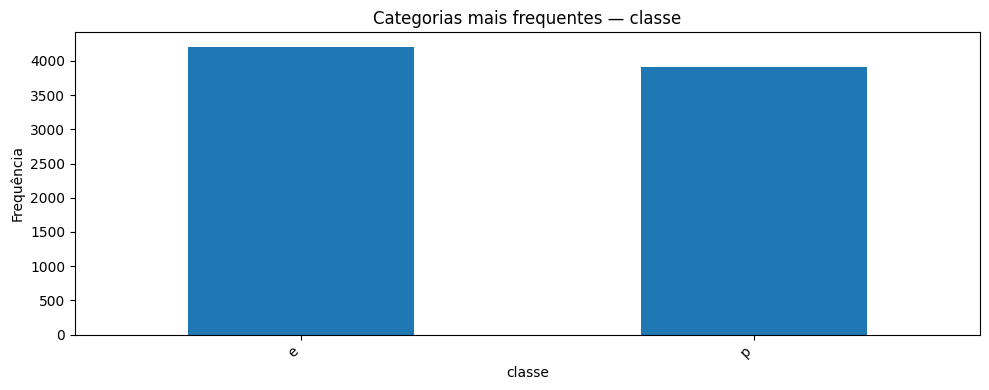

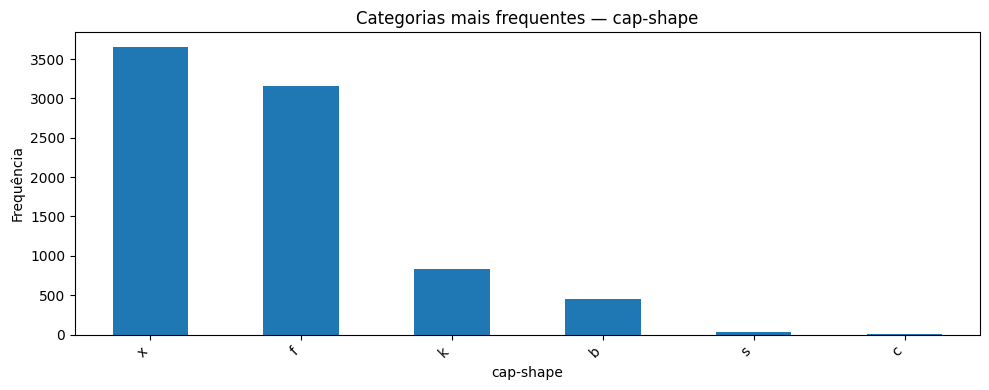

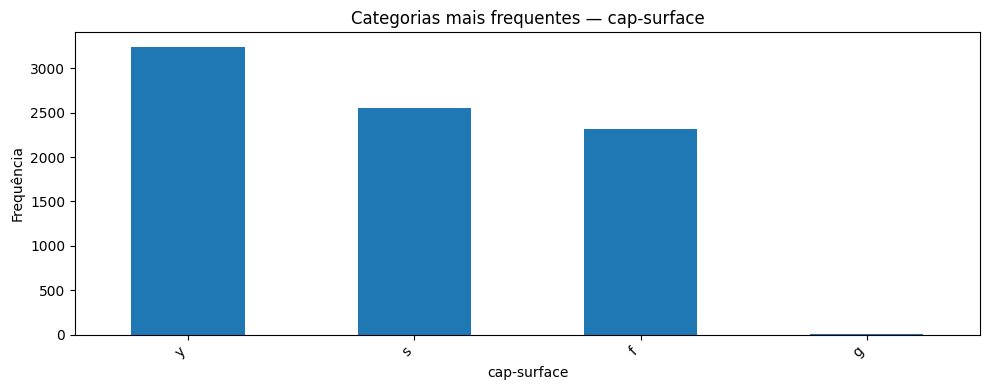

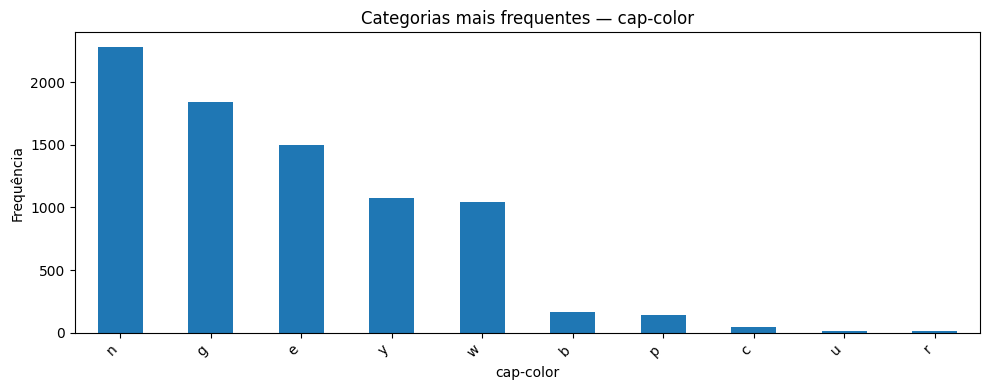

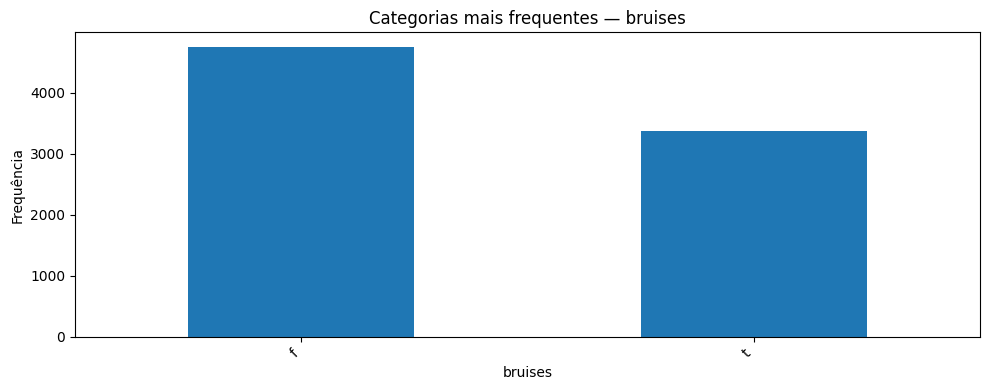

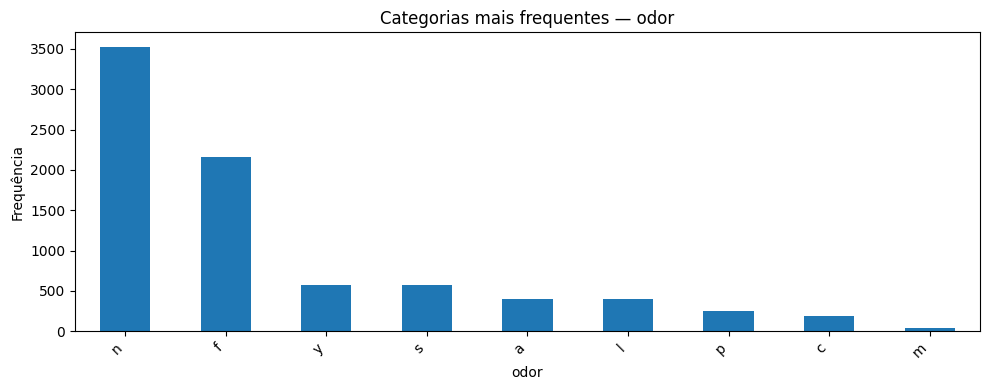

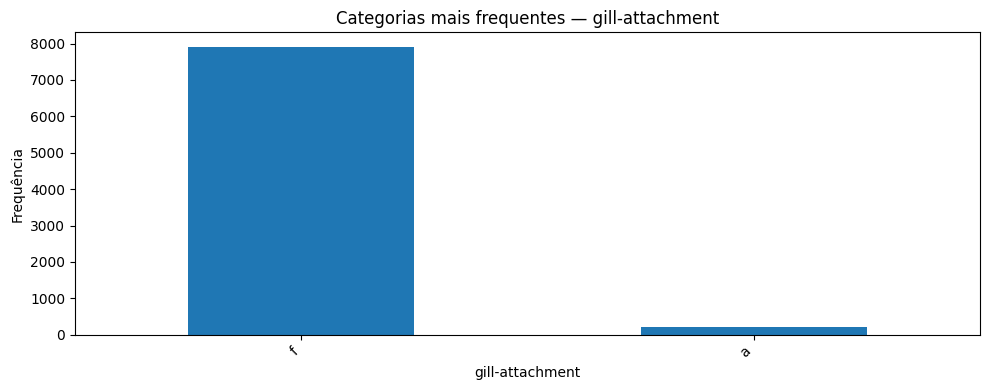

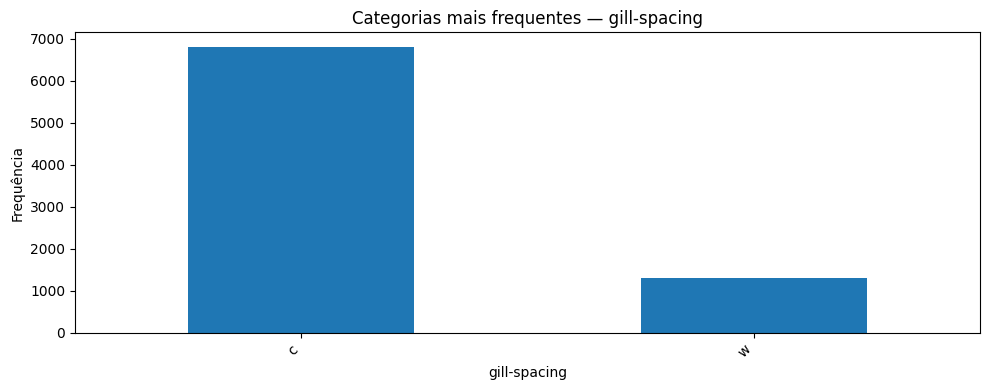

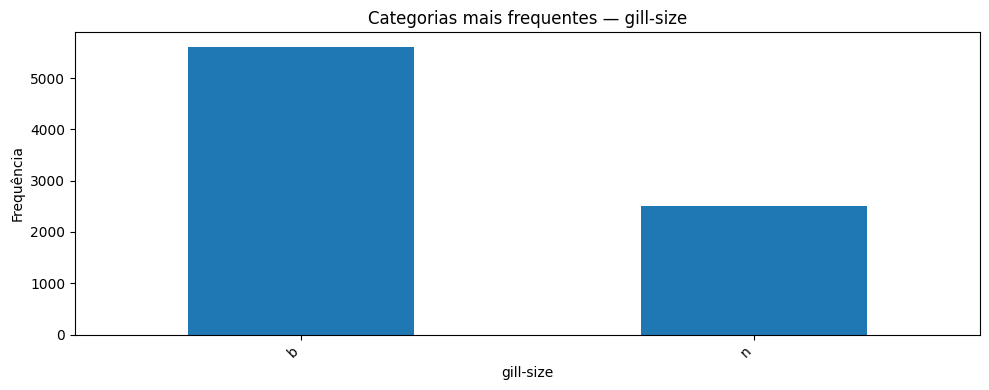

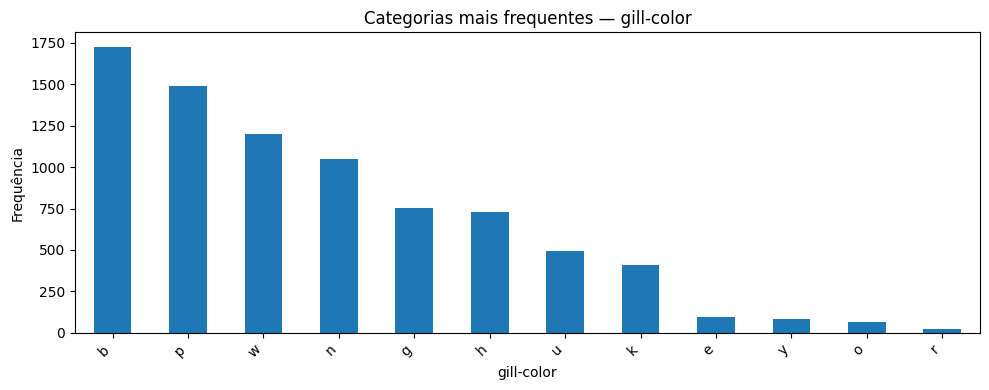

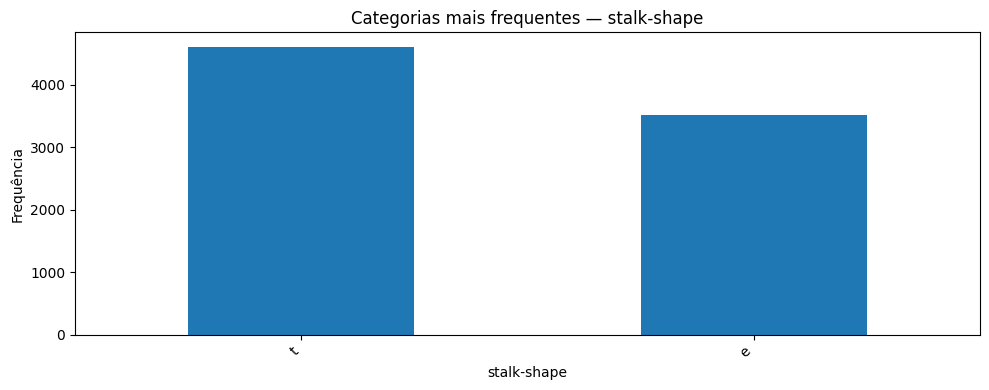

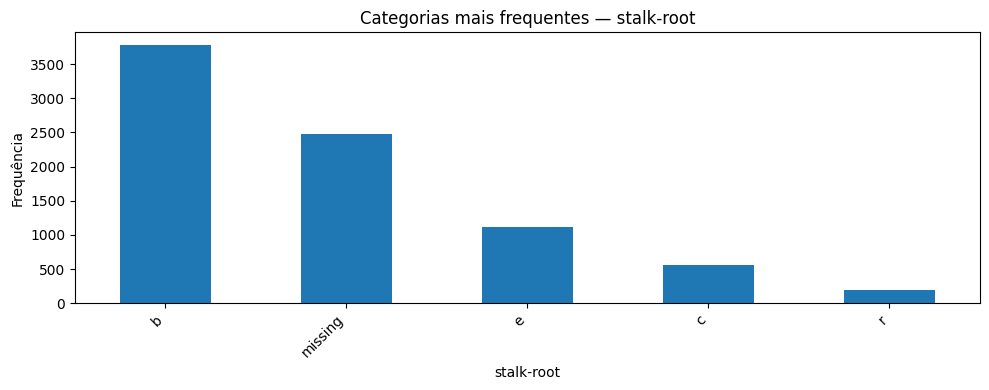

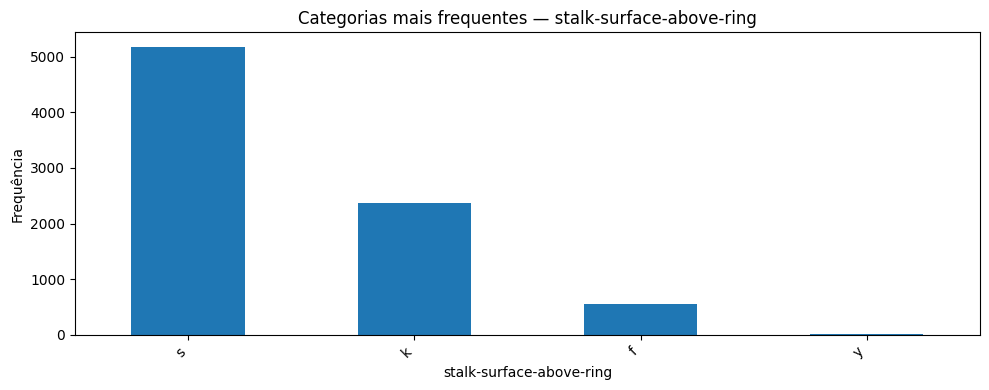

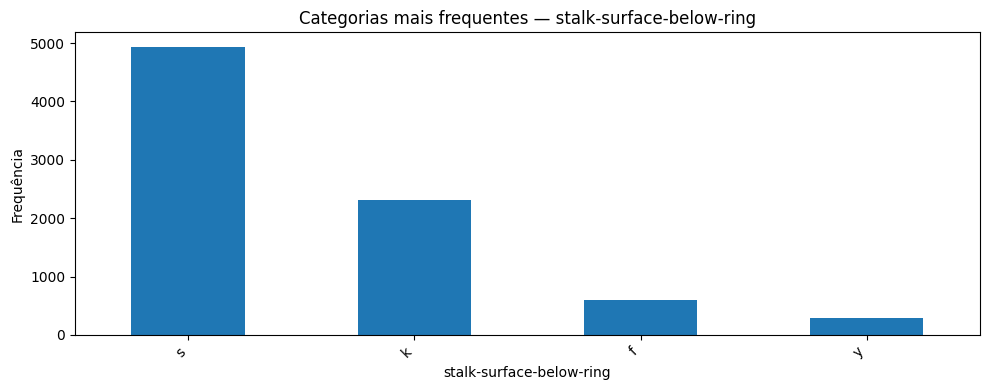

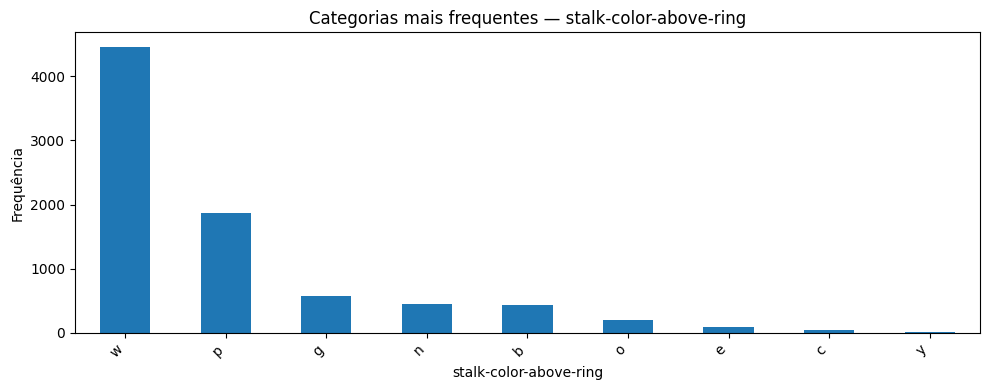

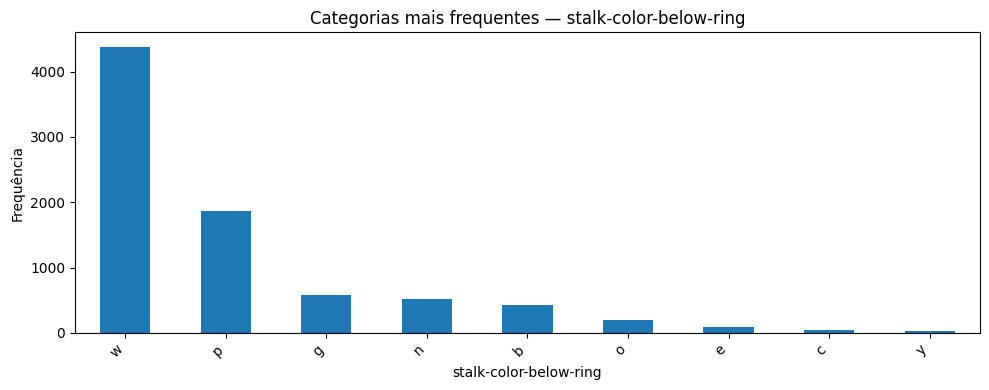

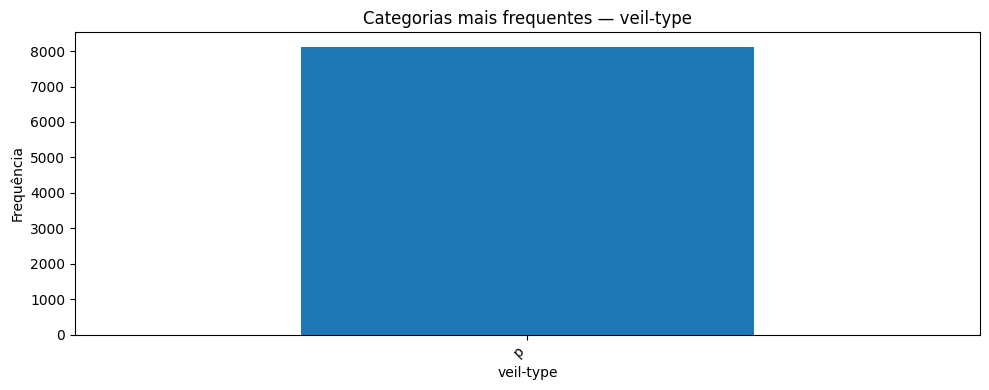

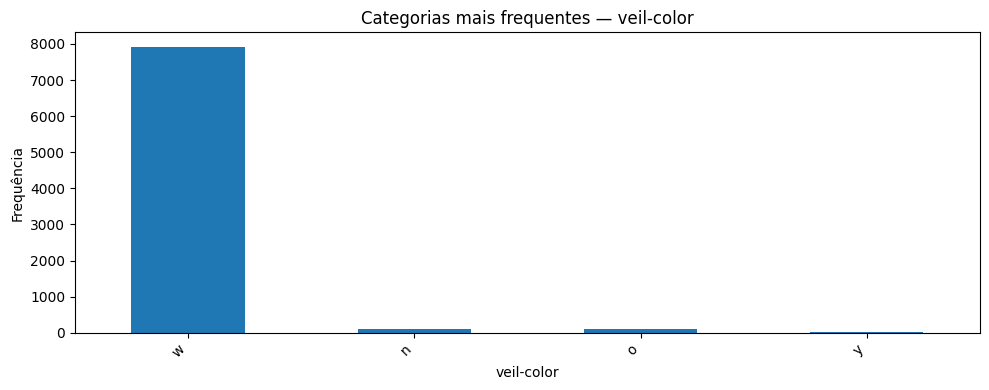

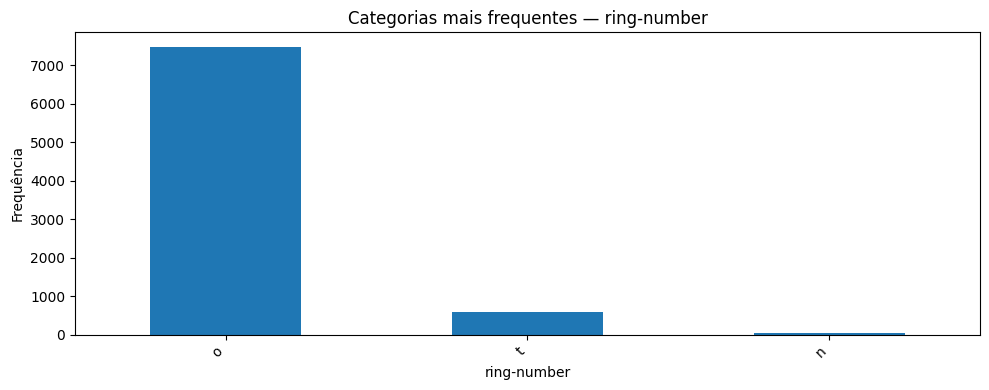

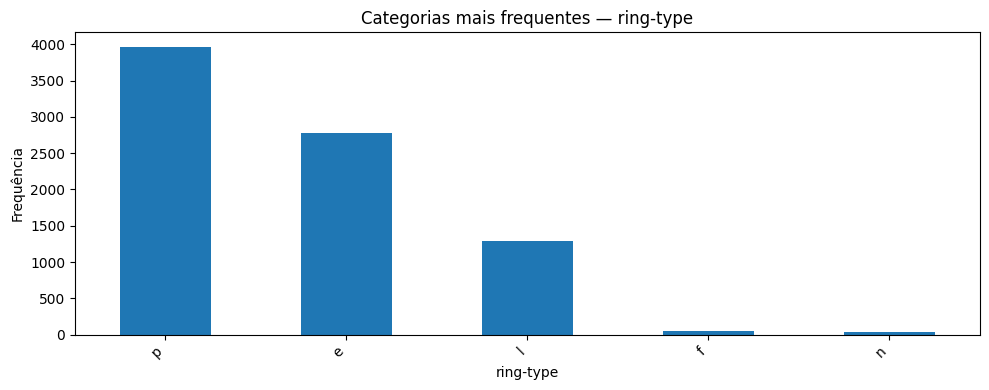

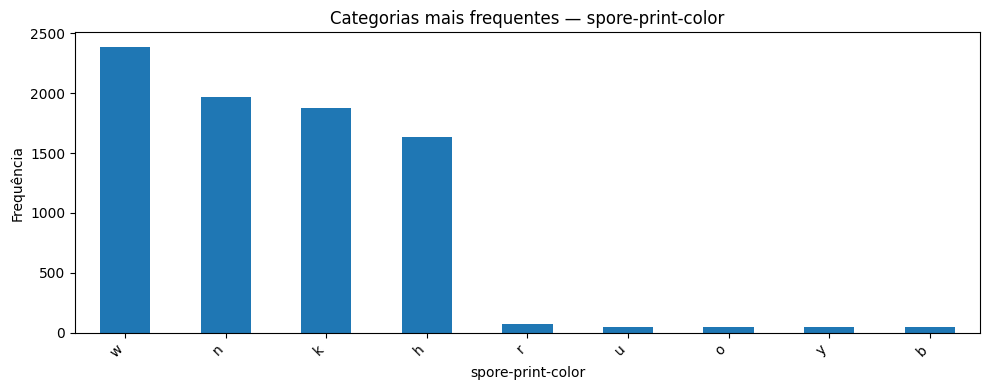

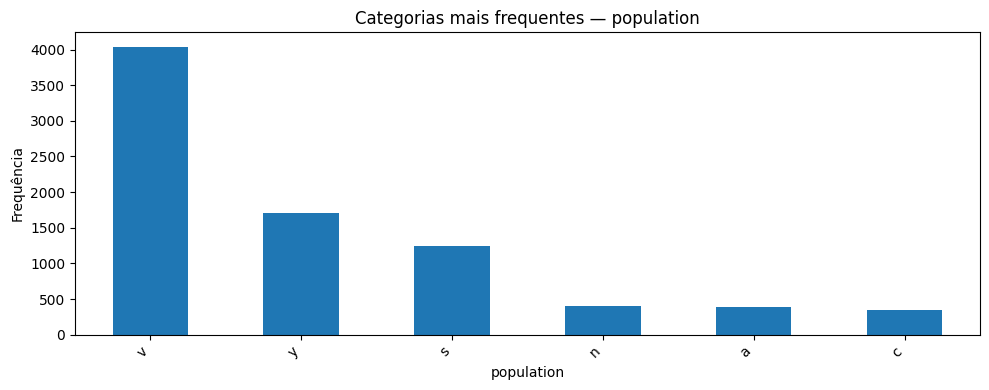

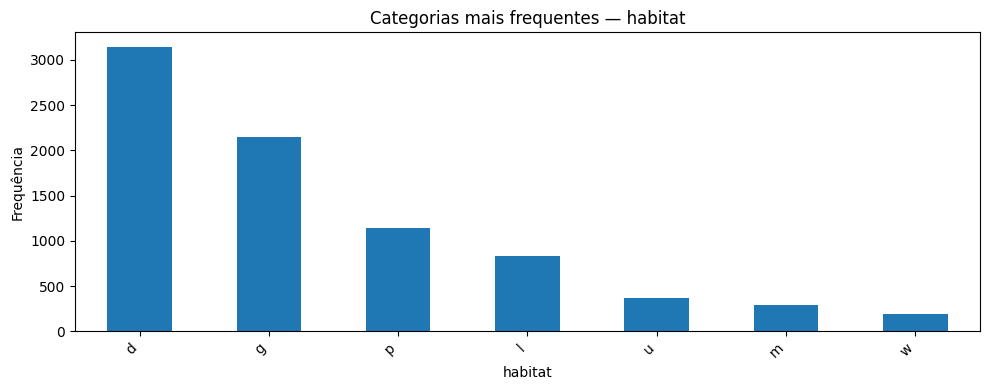

In [12]:
# Funções auxiliares para visualização exploratória
# Adapte as colunas e os gráficos ao dataset.

def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Categorias mais frequentes — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Só temos colunas categoricas, entao vamos plotar a contagem de cada uma.
for name in df.columns:
     plot_contagem_categorica(df, name)

## 2.2 Análise visual e principais insights

**1. Concentração e Desbalanceamento de Valores:**
- Atributos Dominantes: Variáveis como veil-color, ring-number, gill-attachment e veil-type apresentam um desbalanceamento extremo, onde uma única categoria detém quase a totalidade das instâncias. O caso mais crítico é o veil-type, que possui variância zero (100% de valores 'p'), tornando-o irrelevante para a mineração,
- Concentração Multimodal: Em spore-print-color e cap-color, há uma concentração clara em 4 ou 5 categorias principais (como branco e marrom), enquanto as demais cores são raras. Isso indica que as regras com maior Suporte virão dessas combinações cromáticas majoritárias.

**2. Categorias Raras e Riscos (Monitoramento e Avaliação):**
Observamos \"caudas longas\" em diversos atributos, como as cores de chapéu u (roxo) e r (verde), ou o habitat w (resíduos).

- Risco Identificado: Categorias muito raras podem gerar regras com Confiança de 100% de forma espúria (devido ao baixo número de amostras). Para mitigar isso, conforme nossa diretriz de Monitoramento, não confiaremos apenas na confiança, utilizando o Lift para validar se a associação é estatisticamente superior ao acaso.

**3. Padrões de Co-ocorrência Potenciais (Explicabilidade):**

Os atributos de textura, como stalk-surface-above-ring e stalk-surface-below-ring, apresentam distribuições muito similares, sugerindo uma forte correlação entre as partes do caule.
O atributo bruises (manchas) divide o dataset de forma equilibrada, o que é um excelente sinal para a Explicabilidade, pois é uma característica binária de fácil observação que pode servir como um divisor mestre nos antecedentes das regras.

**4. Tratamento de Incertezas:**
O atributo stalk-root possui uma categoria missing expressiva (2.480 ocorrências). A visualização confirma que esta não é uma falha pontual, mas uma característica estrutural de uma grande fatia das amostras. Tratá-la como uma categoria válida, e não como erro, preserva a integridade biológica do modelo.

Tambem incluímos abaixo a contagem de linhas com nulos em stalk_root (que é a unica coluna que pode ter valores `missing`)

In [15]:
# Verificação simples de duplicatas, nulos e possíveis identificadores

def diagnostico_qualidade(df: pd.DataFrame) -> dict:
    if df is None:
        print("Dataset não carregado.")
        return {}

    diagnostico = {
        "n_linhas": df.shape[0],
        "n_colunas": df.shape[1],
        "n_duplicatas_exatas": int(df.duplicated().sum()),
        "colunas_com_nulos": df.columns[df.isna().any()].tolist(),
        "colunas_possiveis_ids": [],
        "linhas_com_nulos_stalk_root": int((df['stalk-root']=='missing').sum())
    }

    for col in df.columns:
        proporcao_unicos = df[col].nunique(dropna=True) / max(len(df), 1)
        if proporcao_unicos > 0.95:
            diagnostico["colunas_possiveis_ids"].append(col)

    return diagnostico

# Exemplo de uso:
diagnostico = diagnostico_qualidade(df)
print(json.dumps(diagnostico, indent=2, ensure_ascii=False))

{
  "n_linhas": 8124,
  "n_colunas": 23,
  "n_duplicatas_exatas": 0,
  "colunas_com_nulos": [],
  "colunas_possiveis_ids": [],
  "linhas_com_nulos_stalk_root": 2480
}


## 2.3 Diagnóstico final de qualidade dos dados

| Problema identificado | Evidência | Decisão Final | Justificativa |
|---|---|---|---|
| Valores ausentes em `stalk-root` | stalk-root\t2.480 ocorrências de ? no gráfico de barras. | MANTER | O valor não é um erro de preenchimento, mas uma característica biológica ou limitação de coleta comum em micologia. Removê-lo causaria perda de 30% do dataset.  |
| Duplicatas |  df.duplicated().sum() (Verificar valor no notebook) | NÃO SE APLICA | O dataset não apresenta registros idênticos, garantindo que cada transação representa uma observação biológica distinta. |
| Outliers (Dados Categóricos) | Gráficos de habitat, cap-shape e cap-color com barras mínimas. | MANTER E MONITORAR | Em dados categóricos, \"outliers\" são categorias raras. Manteremos todas para não ignorar espécimes venenosos raros, usando o Lift para filtrar relevância. |
| Atributos de Variância Zero | Gráfico de veil-type com 100% de frequência em uma única categoria. | REMOVER | Atributos constantes não possuem poder discriminatório. Sua permanência apenas aumenta o custo computacional sem gerar conhecimento. |
| Baixa Variabilidade | Gráficos de veil-color e ring-number (predomínio > 90% de um valor). | MANTER | Embora desbalanceados, possuem variação mínima que pode ser crucial para regras de exceção ligadas à segurança. |

### **Observação sobre responsabilidade**

As decisões de qualidade tomadas aqui reforçam a diretriz de Monitoramento e Avaliação. Ao optar por manter categorias raras e o dado \"missing\" de stalk-root, priorizamos a Explicabilidade biológica sobre a limpeza estatística simplista. A remoção de veil-type atende à eficiência técnica sem prejudicar a segurança, pois um dado que nunca muda não ajuda a explicar por que um cogumelo é ou não venenoso. O uso posterior da métrica Lift será nossa salvaguarda para garantir que as categorias raras não gerem falsas certezas (regras de confiança alta, mas sem relevância estatística).

### **Observação sobre Outliers**
No contexto de dados categóricos, o conceito de 'outlier' é substituído pela identificação de categorias de baixíssima frequência (como as cores de chapéu 'roxo' ou 'verde' observadas nos nossos gráficos). Em vez de removê-las como faríamos com outliers numéricos, optamos por mantê-las ou monitorá-las através da métrica de Lift, pois em segurança biológica, uma característica rara pode ser justamente o diferencial de uma espécie venenosa.


In [16]:
# Preparação final dos dados
# Esta função deve ser adaptada pelo grupo.
# Não use transformações automáticas sem justificar no texto.

def preparar_dados_final(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        raise ValueError("Dataset não carregado.")

    df_prep = df.copy()

    # 1. Remover duplicatas exatas 
    # (Boa prática, mesmo que o resultado atual seja 0)
    df_prep = df_prep.drop_duplicates()

    # 2. Remover colunas sem variância (Atributos constantes)
    # Como vimos nos gráficos, 'veil-type' tem 100% de valores 'p' e deve sair.
    colunas_remover = ["veil-type"]
    df_prep = df_prep.drop(columns=[c for c in colunas_remover if c in df_prep.columns])

    # 3. Tratamento de nulos
    # No nosso caso, o 'stalk-root' já tem o valor 'missing' que criamos no carregamento.
    # Não faremos imputações extras (como moda) para não distorcer os padrões reais.
    
    return df_prep

# Exemplo de uso:
df_prep = preparar_dados_final(df)
print(f"Dimensões originais: {df.shape}")
print(f"Dimensões após preparação: {df_prep.shape}")
display(df_prep.head())

Dimensões originais: (8124, 23)
Dimensões após preparação: (8124, 22)


,classe,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,s,w,w,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,s,w,w,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,s,w,w,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,s,w,w,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,s,w,w,w,o,e,n,a,g


## 2.4 Justificativa da preparação final


A preparação dos dados foi guiada pela necessidade de manter a integridade biológica do dataset, garantindo que a simplificação estatística não gerasse pontos cegos na identificação de riscos.

**1. Remoção de Colunas:** Foi removida apenas a coluna `veil-type`. A justificativa é técnica: por apresentar variância zero (todas as amostras possuem o mesmo valor), ela não possui poder discriminatório para algoritmos de associação, sendo apenas ruído computacional.

**2. Tratamento de Valores Ausentes:** Em conformidade com a análise de qualidade, os valores `?` do atributo `stalk-root` foram mantidos e rotulados como uma categoria explícita (`missing`). Decidimos não realizar imputação (como preencher com a moda), pois em um contexto de segurança, inventar um valor para a raiz do cogumelo poderia gerar regras falsas e perigosas.

**3. Tratamento de Variáveis Categóricas:** O dataset é integralmente categórico. Para a etapa de mineração de padrões, os dados foram mantidos em seu formato nominal original, apenas garantindo a limpeza de espaços em branco. A transformação para formato transacional (ou One-Hot Encoding) será realizada na fase de modelagem, conforme a exigência de cada algoritmo.

**4. Normalização, Discretização e Outliers:** Não houve necessidade de normalização ou discretização, dada a ausência de variáveis numéricas. Da mesma forma, a remoção de outliers pelo método IQR foi descartada por ser incompatível com dados nominais. Categorias raras foram mantidas para preservar a diversidade biológica.

**5. Riscos Introduzidos:** O principal risco é a manutenção de categorias com baixíssimo suporte. Isso pode levar à geração de regras de associação muito específicas que, embora tenham 100% de confiança no treino, podem não ser generalizáveis na natureza. Esse risco será mitigado na fase de avaliação através do uso do *Lift*.

**6. Relação com as Diretrizes:**
* **Explicabilidade:** Ao optar por não agrupar ou codificar demais as categorias agora, garantimos que os antecedentes das regras sejam diretamente rastreáveis às características físicas reais do cogumelo.
* **Monitoramento e Avaliação:** A decisão de manter o dado "missing" e as categorias raras reflete um rigor ético: é preferível que o sistema aponte "desconhecido" do que forneça uma classificação errada baseada em dados imputados artificialmente.

**Sugestão que a LLM ofereceu e foi acatada**
A LLM havia mencionado que todas as linhas de veil-type eram iguais, após uma análise do Dataset, confirmamos que isso é verdade, e removemos, já que ela não adiciona nenhuma variância aos dados.


# 3. Modeling

Nesta seção, o grupo deve implementar a solução final.

A modelagem final deve ser resultado de uma decisão crítica, não de simples cópia da LLM.

A seção deve deixar claro:

- quais algoritmos foram testados;
- quais parâmetros foram usados;
- por que esses algoritmos foram escolhidos;
- o que foi inspirado pela baseline;
- o que foi inspirado pela trilha guiada;
- o que foi corrigido ou decidido pelo grupo;
- como a implementação se relaciona às diretrizes de IA responsável.

## 3.1 Comparação entre baseline, guiada e solução final

| Elemento | Sugestão baseline | Sugestão guiada | Solução final do grupo | Justificativa da decisão final |
|---|---|---|---|---|
| Algoritmo(s) | [PREENCHER] | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Preparação dos dados | [PREENCHER] | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Parâmetros | [PREENCHER] | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Métricas | [PREENCHER] | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Estratégia de avaliação | [PREENCHER] | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Cuidados de IA responsável | [PREENCHER] | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |

### Síntese da decisão final

[DESCREVER A SOLUÇÃO FINAL E JUSTIFICAR POR QUE ELA FOI ESCOLHIDA]

A solução final não precisa ser idêntica à melhor resposta da LLM. Ela deve ser tecnicamente defensável e baseada em evidências.

In [ ]:
# Registro simples de experimentos
# Ajuda a manter rastreabilidade de parâmetros e resultados.

experimentos = []


def registrar_experimento(nome: str, algoritmo: str, parametros: dict, metricas: dict, observacoes: str = ""):
    registro = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "nome": nome,
        "algoritmo": algoritmo,
        "parametros": parametros,
        "metricas": metricas,
        "observacoes": observacoes
    }
    experimentos.append(registro)
    return registro


def salvar_experimentos(caminho: str = os.path.join(OUTPUT_DIR, "experimentos.json")):
    with open(caminho, "w", encoding="utf-8") as f:
        json.dump(experimentos, f, indent=2, ensure_ascii=False)
    print(f"Experimentos salvos em: {caminho}")

# Exemplo:
# registrar_experimento(
#     nome="teste_inicial",
#     algoritmo="Apriori",
#     parametros={"min_support": 0.05, "min_confidence": 0.6},
#     metricas={"n_regras": 100, "tempo_segundos": 1.23},
#     observacoes="Teste preliminar."
# )

## 3.2 Modelagem para padrões frequentes

Use esta seção se o TP atual for de mineração de padrões frequentes.

Caso o TP seja de agrupamento ou classificação, mantenha apenas como referência e utilize as seções correspondentes abaixo.

In [ ]:
# Preparações específicas por tipo de tarefa
# Use apenas o bloco correspondente ao TASK_TYPE do trabalho.

from typing import List, Tuple, Optional


def gerar_transacoes_de_coluna(df: pd.DataFrame, coluna: str, separador: str = ",") -> List[List[str]]:
    """Gera transações para mineração de padrões frequentes a partir de uma coluna textual."""
    transacoes = []

    for valor in df[coluna].dropna():
        itens = [item.strip().lower() for item in str(valor).split(separador) if item.strip()]
        if itens:
            transacoes.append(itens)

    return transacoes


def preparar_matriz_modelagem(df: pd.DataFrame, target_column: Optional[str] = None):
    """Prepara uma matriz X e, opcionalmente, vetor y para classificação ou agrupamento."""
    df_model = df.copy()

    if target_column is not None:
        y = df_model[target_column]
        X = df_model.drop(columns=[target_column])
    else:
        y = None
        X = df_model

    # Codificação one-hot simples para variáveis categóricas.
    # Em trabalhos finais, justificar se esta codificação é adequada.
    X = pd.get_dummies(X, drop_first=False)

    return X, y

# Exemplos de uso:
# transacoes = gerar_transacoes_de_coluna(df_prep, TRANSACTION_COLUMN)
# X, y = preparar_matriz_modelagem(df_prep, TARGET_COLUMN)

In [ ]:
# Modelagem para padrões frequentes: Apriori e FP-Growth
# Esta célula depende de mlxtend. Instale se necessário: pip install mlxtend


def executar_padroes_frequentes(transacoes, min_support=0.05, min_confidence=0.6):
    try:
        from mlxtend.preprocessing import TransactionEncoder
        from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    except ImportError:
        print("Biblioteca mlxtend não instalada. Instale com: pip install mlxtend")
        return None

    te = TransactionEncoder()
    matriz = te.fit(transacoes).transform(transacoes)
    df_transacoes = pd.DataFrame(matriz, columns=te.columns_)

    resultados = {}

    inicio = time.time()
    itemsets_apriori = apriori(df_transacoes, min_support=min_support, use_colnames=True)
    regras_apriori = association_rules(itemsets_apriori, metric="confidence", min_threshold=min_confidence)
    tempo_apriori = time.time() - inicio

    resultados["Apriori"] = {
        "itemsets": itemsets_apriori,
        "regras": regras_apriori,
        "tempo_segundos": tempo_apriori
    }

    inicio = time.time()
    itemsets_fpgrowth = fpgrowth(df_transacoes, min_support=min_support, use_colnames=True)
    regras_fpgrowth = association_rules(itemsets_fpgrowth, metric="confidence", min_threshold=min_confidence)
    tempo_fpgrowth = time.time() - inicio

    resultados["FP-Growth"] = {
        "itemsets": itemsets_fpgrowth,
        "regras": regras_fpgrowth,
        "tempo_segundos": tempo_fpgrowth
    }

    return resultados


def resumir_padroes_frequentes(resultados):
    if resultados is None:
        return pd.DataFrame()

    linhas = []

    for algoritmo, info in resultados.items():
        itemsets = info["itemsets"]
        regras = info["regras"]

        linhas.append({
            "algoritmo": algoritmo,
            "n_itemsets": len(itemsets),
            "n_regras": len(regras),
            "tempo_segundos": round(info["tempo_segundos"], 4),
            "confianca_media": regras["confidence"].mean() if len(regras) > 0 else np.nan,
            "lift_medio": regras["lift"].mean() if len(regras) > 0 and "lift" in regras.columns else np.nan
        })

    return pd.DataFrame(linhas)

# Exemplo de uso:
# transacoes = gerar_transacoes_de_coluna(df_prep, TRANSACTION_COLUMN)
# resultados_padroes = executar_padroes_frequentes(transacoes, min_support=0.05, min_confidence=0.6)
# resumo_padroes = resumir_padroes_frequentes(resultados_padroes)
# display(resumo_padroes)

## 3.3 Modelagem para agrupamento

Use esta seção se o TP atual for de clusterização.

A avaliação de agrupamento deve considerar métricas internas, interpretação dos grupos e coerência com o problema. Não basta reportar o número de clusters.

In [ ]:
# Modelagem para agrupamento: K-Means e DBSCAN
# Adapte os algoritmos conforme a proposta do grupo.


def executar_agrupamento_basico(X: pd.DataFrame):
    try:
        from sklearn.preprocessing import StandardScaler
        from sklearn.cluster import KMeans, DBSCAN
        from sklearn.metrics import silhouette_score, davies_bouldin_score
    except ImportError:
        print("scikit-learn não está instalado.")
        return pd.DataFrame(), {}

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    resultados = []
    modelos = {}

    # K-Means com alguns valores de k como exemplo.
    for k in [2, 3, 4, 5]:
        inicio = time.time()
        modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = modelo.fit_predict(X_scaled)
        tempo = time.time() - inicio

        if len(set(labels)) > 1:
            sil = silhouette_score(X_scaled, labels)
            db = davies_bouldin_score(X_scaled, labels)
        else:
            sil = np.nan
            db = np.nan

        nome = f"KMeans_k{k}"
        modelos[nome] = modelo
        resultados.append({
            "modelo": nome,
            "n_clusters": len(set(labels)),
            "silhouette": sil,
            "davies_bouldin": db,
            "tempo_segundos": tempo
        })

    # DBSCAN com parâmetros de exemplo.
    inicio = time.time()
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    tempo = time.time() - inicio

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        sil = silhouette_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
    else:
        sil = np.nan
        db = np.nan

    modelos["DBSCAN"] = dbscan
    resultados.append({
        "modelo": "DBSCAN",
        "n_clusters": n_clusters,
        "silhouette": sil,
        "davies_bouldin": db,
        "tempo_segundos": tempo
    })  

    return pd.DataFrame(resultados), modelos

# Exemplo de uso:
# X, _ = preparar_matriz_modelagem(df_prep, target_column=None)
# resultados_cluster, modelos_cluster = executar_agrupamento_basico(X)
# display(resultados_cluster)

## 3.4 Modelagem para classificação

Use esta seção se o TP atual for de classificação.

A avaliação deve usar uma separação adequada entre treino e teste ou validação cruzada, além de métricas coerentes com o problema, especialmente se houver desbalanceamento de classes.

In [ ]:
# Modelagem para classificação: exemplos com árvore, regressão logística e random forest
# Adapte os modelos conforme a proposta do grupo.


def executar_classificacao_basica(X: pd.DataFrame, y: pd.Series, test_size: float = 0.2):
    try:
        from sklearn.model_selection import train_test_split
        from sklearn.preprocessing import StandardScaler
        from sklearn.pipeline import Pipeline
        from sklearn.tree import DecisionTreeClassifier
        from sklearn.linear_model import LogisticRegression
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    except ImportError:
        print("scikit-learn não está instalado.")
        return pd.DataFrame(), {}

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y if y.nunique() > 1 else None
    )

    modelos = {
        "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),
        "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)
    }

    resultados = []
    modelos_treinados = {}

    average = "weighted" if y.nunique() > 2 else "binary"

    for nome, modelo in modelos.items():
        inicio = time.time()
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        tempo = time.time() - inicio

        resultados.append({
            "modelo": nome,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, average=average, zero_division=0),
            "recall": recall_score(y_test, y_pred, average=average, zero_division=0),
            "f1": f1_score(y_test, y_pred, average=average, zero_division=0),
            "tempo_segundos": tempo
        })

        modelos_treinados[nome] = modelo

    return pd.DataFrame(resultados), modelos_treinados

# Exemplo de uso:
# X, y = preparar_matriz_modelagem(df_prep, TARGET_COLUMN)
# resultados_classificacao, modelos_classificacao = executar_classificacao_basica(X, y)
# display(resultados_classificacao)

## 3.5 Resultados da modelagem final

[INSERIR RESULTADOS EFETIVAMENTE OBTIDOS]

Inclua tabelas e comentários sobre:

- algoritmos executados;
- parâmetros usados;
- métricas obtidas;
- tempo de execução;
- estabilidade ou sensibilidade a parâmetros;
- qualidade dos padrões, clusters ou classificações;
- interpretabilidade dos resultados;
- relação com as diretrizes escolhidas.

### Interpretação técnica

[INSERIR INTERPRETAÇÃO]

Evite conclusões vagas. Exemplos de frases fracas:

- “O algoritmo foi bom.”
- “O resultado foi satisfatório.”
- “A LLM ajudou bastante.”

Prefira afirmações verificáveis:

- “O FP-Growth gerou o mesmo conjunto de itemsets que o Apriori, mas com menor tempo de execução neste dataset.”
- “O modelo de árvore teve desempenho inferior, mas permitiu interpretação mais direta das regras de decisão.”
- “O K-Means com k=3 apresentou melhor silhouette entre os valores testados, mas a interpretação dos clusters ainda é limitada.”

# 4. Evaluation

Nesta seção, o grupo deve avaliar a solução final de forma crítica.

A avaliação deve considerar:

- qualidade dos resultados;
- adequação ao problema de negócio;
- desempenho dos algoritmos;
- limitações dos dados;
- limitações da modelagem;
- influência real das LLMs;
- influência real das diretrizes de IA responsável;
- trade-offs observados.

## 4.1 Avaliação dos resultados finais

[INSERIR ANÁLISE DOS RESULTADOS]

A análise deve responder:

- Os resultados são coerentes com o problema?
- Os padrões, clusters ou classificações têm interpretação útil?
- As métricas usadas são adequadas?
- Há sinais de overfitting, instabilidade ou resultado trivial?
- Os resultados dependem fortemente de parâmetros?
- As conclusões são sustentadas pelos dados?

### Limitações dos resultados

[DESCREVER LIMITAÇÕES]

Exemplos:

- dataset desbalanceado;
- atributos pouco informativos;
- ausência de variáveis importantes;
- muitos dados ausentes;
- limitações de escala;
- dificuldade de interpretar padrões numerosos ou redundantes.

## 4.2 Comparação final: baseline × guiada × solução final

| Critério | Baseline sugerida pela LLM | Guiada sugerida pela LLM | Solução final implementada | Avaliação crítica |
|---|---|---|---|---|
| Correção técnica | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Adequação ao problema | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Preparação dos dados | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Algoritmos escolhidos | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Métricas de avaliação | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Interpretabilidade | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Rastreabilidade | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Eficiência computacional | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Aderência às diretrizes | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |

### Conclusão da comparação

[INSERIR CONCLUSÃO COMPARATIVA]

A conclusão deve deixar claro:

- o que a baseline acertou;
- o que a baseline ignorou;
- o que a trilha guiada melhorou;
- o que a trilha guiada ainda errou;
- o que o grupo decidiu implementar;
- por que a solução final é tecnicamente mais defensável.

## 4.3 Sugestões aceitas, rejeitadas e corrigidas

| Sugestão | Origem | Decisão | Justificativa |
|---|---|---|---|
| [SUGESTÃO 1] | Baseline | Aceita / Rejeitada / Corrigida | [JUSTIFICAR] |
| [SUGESTÃO 2] | Guiada | Aceita / Rejeitada / Corrigida | [JUSTIFICAR] |
| [SUGESTÃO 3] | Grupo | Implementada | [JUSTIFICAR] |

### Erros ou limitações das LLMs

| Erro, omissão ou limitação | Trilha | Impacto potencial | Correção feita pelo grupo |
|---|---|---|---|
| [DESCREVER] | Baseline / Guiada | [DESCREVER] | [DESCREVER] |
| [DESCREVER] | Baseline / Guiada | [DESCREVER] | [DESCREVER] |

> O grupo deve demonstrar que avaliou criticamente a LLM. Uma boa entrega não aceita automaticamente todas as recomendações geradas.

## 4.4 Avaliação das diretrizes de IA responsável na solução final

| Diretriz | Como apareceu na Fase 2 | Como foi incorporada na Fase 3 | Evidência no notebook | Limitações |
|---|---|---|---|---|
| [DIRETRIZ 1] | [DESCREVER] | [DESCREVER] | [INSERIR EVIDÊNCIA] | [DESCREVER] |
| [DIRETRIZ 2] | [DESCREVER] | [DESCREVER] | [INSERIR EVIDÊNCIA] | [DESCREVER] |

### Discussão crítica

[INSERIR DISCUSSÃO]

Questões orientadoras:

- A diretriz influenciou apenas o texto ou também o pipeline técnico?
- Houve mudança em atributos, algoritmos, métricas ou interpretação?
- A diretriz melhorou a qualidade da solução?
- Houve custo adicional, perda de desempenho ou aumento de complexidade?
- Alguma diretriz foi difícil de operacionalizar? Por quê?

## 4.5 Trade-offs finais

| Trade-off | Evidência observada | Decisão final | Justificativa |
|---|---|---|---|
| Desempenho × interpretabilidade | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Privacidade × utilidade dos dados | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Eficiência × qualidade dos resultados | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Simplicidade × completude da análise | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Justiça/viés × disponibilidade de atributos | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |

### Síntese

[INSERIR SÍNTESE DOS TRADE-OFFS MAIS IMPORTANTES]

Nem todos os trade-offs serão aplicáveis a todos os trabalhos. Discuta apenas os que fizerem sentido para o dataset e para a tarefa.

# 5. Conclusão

[INSERIR CONCLUSÃO FINAL]

A conclusão deve retomar:

1. o objetivo do trabalho;
2. a solução final implementada;
3. os principais resultados obtidos;
4. as limitações da análise;
5. o papel das LLMs;
6. o efeito das diretrizes de IA responsável;
7. possíveis melhorias futuras.

## Exemplo de estrutura de conclusão

> Neste trabalho, investigamos [PROBLEMA] usando o dataset [DATASET] e aplicamos [TÉCNICA]. Após comparar as sugestões da LLM nas condições baseline e guiada, decidimos implementar [SOLUÇÃO FINAL]. Os resultados indicam que [SÍNTESE DOS RESULTADOS], com limitações relacionadas a [LIMITAÇÕES]. A explicitação das diretrizes de [DIRETRIZ 1] e [DIRETRIZ 2] contribuiu para [EFEITO CONCRETO], embora [TRADE-OFF OU LIMITAÇÃO].

> Substitua o exemplo por uma conclusão real, baseada nos resultados executados.

# 6. Checklist final da Fase 3

Antes de entregar, verifique se o notebook contém:

- [ ] identificação do grupo;
- [ ] link público do dataset;
- [ ] validação das restrições mínimas do dataset;
- [ ] Business Understanding consolidado;
- [ ] descrição clara do dataset;
- [ ] dicionário de dados;
- [ ] diretrizes de IA responsável escolhidas;
- [ ] explicação de como as diretrizes influenciaram a solução final;
- [ ] Data Understanding com tabelas, gráficos e interpretação;
- [ ] Data Preparation com justificativa das decisões;
- [ ] modelagem final executada;
- [ ] parâmetros documentados;
- [ ] métricas adequadas à tarefa;
- [ ] resultados interpretados;
- [ ] comparação baseline × guiada × solução final;
- [ ] sugestões aceitas, rejeitadas e corrigidas;
- [ ] erros e limitações das LLMs;
- [ ] trade-offs discutidos;
- [ ] conclusão final baseada em evidências;
- [ ] referências utilizadas.

# 7. Referências

[INSERIR REFERÊNCIAS UTILIZADAS]

Inclua, quando aplicável:

- documentação do dataset;
- materiais da disciplina;
- documentação das bibliotecas;
- referências sobre CRISP-DM;
- referências sobre algoritmos utilizados;
- referências sobre IA responsável;
- artigos ou livros usados para embasar decisões técnicas.

> As referências devem apoiar decisões reais do trabalho. Evite listar referências que não foram usadas na análise.

# 8. Apêndice opcional — detalhes adicionais

Use esta seção para incluir materiais complementares que não cabem no corpo principal do notebook, por exemplo:

- tabelas extensas;
- resultados de experimentos secundários;
- variações de parâmetros;
- prompts resumidos da Fase 2, se o grupo julgar necessário;
- detalhes de implementação;
- análises adicionais não centrais.

> O apêndice não substitui as seções principais. Ele deve apenas complementar a argumentação.

In [ ]:
# Célula opcional para salvar uma versão resumida dos principais artefatos gerados
# Adapte conforme os objetos produzidos no notebook.

# Exemplos:
# resumo_padroes.to_csv(os.path.join(OUTPUT_DIR, "resumo_padroes.csv"), index=False)
# resultados_cluster.to_csv(os.path.join(OUTPUT_DIR, "resultados_cluster.csv"), index=False)
# resultados_classificacao.to_csv(os.path.join(OUTPUT_DIR, "resultados_classificacao.csv"), index=False)
# salvar_experimentos()

print("Use esta célula apenas após gerar os artefatos finais do trabalho.")